# Deck Views
Standalone chart renderings pulled directly into the presentation.

### - Establish Visualization Standards

In [1]:
# ============================================================
# Imports & Visualization Standards
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

# Standard color palette (order: Blue, Red, Teal, Yellow)
PALETTE = ['#0000a2', '#bc272d', '#50ad9f', '#e9c716']

# Standard figure size for all charts
FIGSIZE = (22, 8.5)

# Axis formatters
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}K'

def millions_formatter(x, pos):
    return f'${x/1_000_000:,.1f}M'

def millions_plain_formatter(x, pos):
    return f'{x/1_000_000:,.1f}M'

# Standard label styling
TITLE_STYLE = {'fontsize': 18, 'fontweight': 'bold'}
LABEL_STYLE = {'fontsize': 16, 'fontweight': 'bold'}
LEGEND_STYLE = {'fontsize': 14, 'title_fontsize': 0}

# Shared constants used across multiple analysis cells
YEARS = [2021, 2022, 2023]
YEAR_COLORS = dict(zip(YEARS, PALETTE))
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_ORDER = ['April', 'May', 'June', 'July', 'August', 'September']
DAYNIGHT_ORDER = ['Day Game', 'Night Game']
BAR_WIDTH = 0.25

### - Load in Data

In [2]:
full = pd.read_csv('../step_01_clean_data/clean_data.csv', parse_dates=['Game Date'])

print(f"Loaded: {full.shape[0]} rows, {full.shape[1]} columns")
full.head()

Loaded: 243 rows, 26 columns


,Home Game #,Game Date,Year,Month,Day of Week,Weekend / Weekday,Game Time,Day/Night,Full Season Tickets (#),Full Season Revenue ($),...,Group Avg Price ($),Single Game Tickets (#),Single Game Revenue ($),Single Game Avg Price ($),No-Show Rate,Total Tickets (#),Actual Attendance (#),Total Revenue ($),Average Ticket Price ($),Is First Month
0,1,2021-04-01,2021,April,Thursday,Weekday,13:10:00,Day Game,9361,417794.04,...,46.83,16916,1013906.60,59.94,0.1420,36688,31478,1870492.51,50.98,True
1,2,2021-04-02,2021,April,Friday,Weekend,19:10:00,Night Game,9374,415278.62,...,25.93,9023,272800.32,30.23,0.1752,24520,20224,852818.98,34.78,True
2,3,2021-04-03,2021,April,Saturday,Weekend,18:10:00,Night Game,9398,414149.54,...,30.51,10411,373733.78,35.90,0.1643,28927,24174,1057199.15,36.55,True
3,4,2021-04-04,2021,April,Sunday,Weekend,13:10:00,Day Game,9374,415431.58,...,30.16,12149,411154.96,33.84,0.1609,28561,23966,1057229.43,37.02,True
4,5,2021-04-09,2021,April,Friday,Weekend,19:10:00,Night Game,9376,416211.65,...,30.28,10282,408009.37,39.68,0.1570,29910,25214,1141873.37,38.18,True


### Single Game Decline (M/T/W/Sun) & Full Season Price Correlation

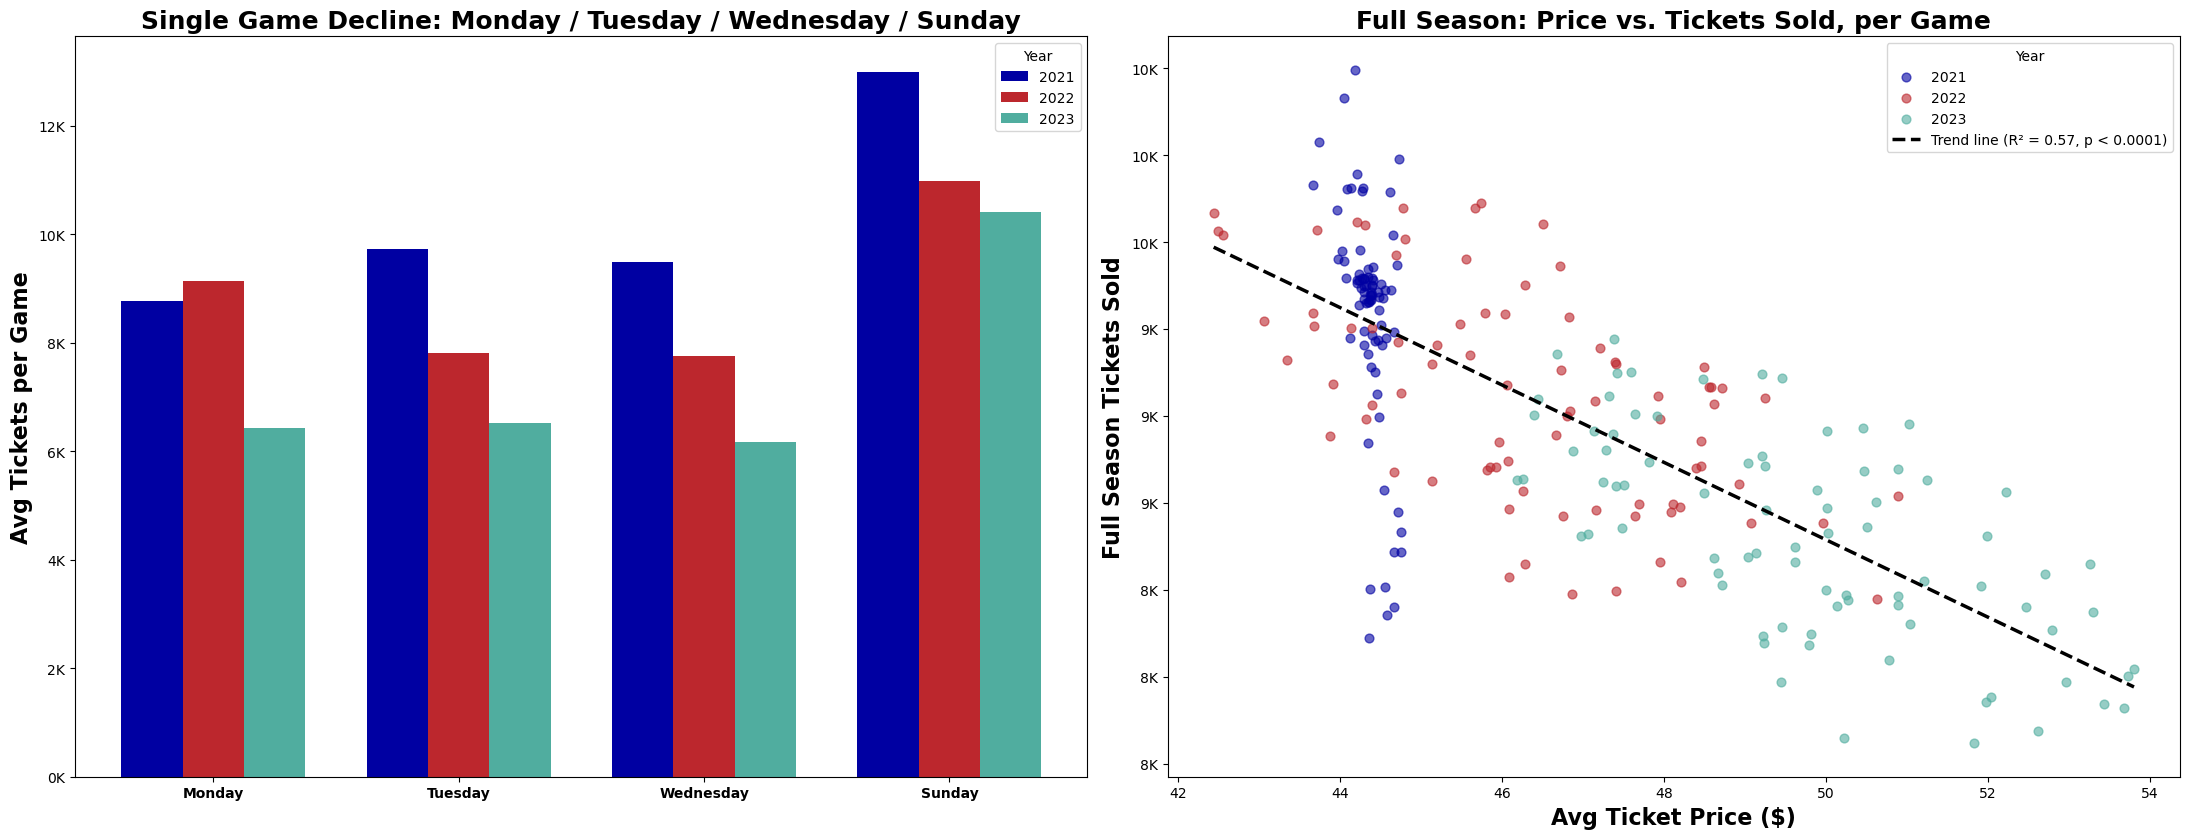

In [3]:
# LEFT data: Single Game avg tickets, Monday/Tuesday/Wednesday/Sunday
mtws_order = ['Monday', 'Tuesday', 'Wednesday', 'Sunday']
ticket_pivot_mtws = full.groupby(['Year', 'Day of Week'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=mtws_order)

# RIGHT data: Full Season price/attendance regression
x = full['Full Season Avg Price ($)']
y = full['Full Season Tickets (#)']
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# LEFT: Single Game decline, Monday/Tuesday/Wednesday/Sunday
ax = axes[0]
xi_range = range(len(mtws_order))
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax.bar([xi + i * BAR_WIDTH for xi in xi_range], ticket_pivot_mtws.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax.set_title('Single Game Decline: Monday / Tuesday / Wednesday / Sunday', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in xi_range])
ax.set_xticklabels(mtws_order, fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(title='Year', loc='upper right')

# RIGHT: Full Season price/attendance correlation
ax2 = axes[1]
for year, color in YEAR_COLORS.items():
    mask = full['Year'] == year
    ax2.scatter(full.loc[mask, 'Full Season Avg Price ($)'], full.loc[mask, 'Full Season Tickets (#)'],
                color=color, alpha=0.6, s=40, label=str(year))
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax2.plot(x_line, y_line, color='black', linewidth=2.5, linestyle='dashed',
         label=f'Trend line (R² = {r_value**2:.2f}, p < 0.0001)')
ax2.set_title('Full Season: Price vs. Tickets Sold, per Game', **TITLE_STYLE)
ax2.set_xlabel('Avg Ticket Price ($)', **LABEL_STYLE)
ax2.set_ylabel('Full Season Tickets Sold', **LABEL_STYLE)
ax2.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax2.legend(title='Year', loc='upper right')

plt.tight_layout()
plt.show()

### Full Season: Price vs. Attendance (Standalone)

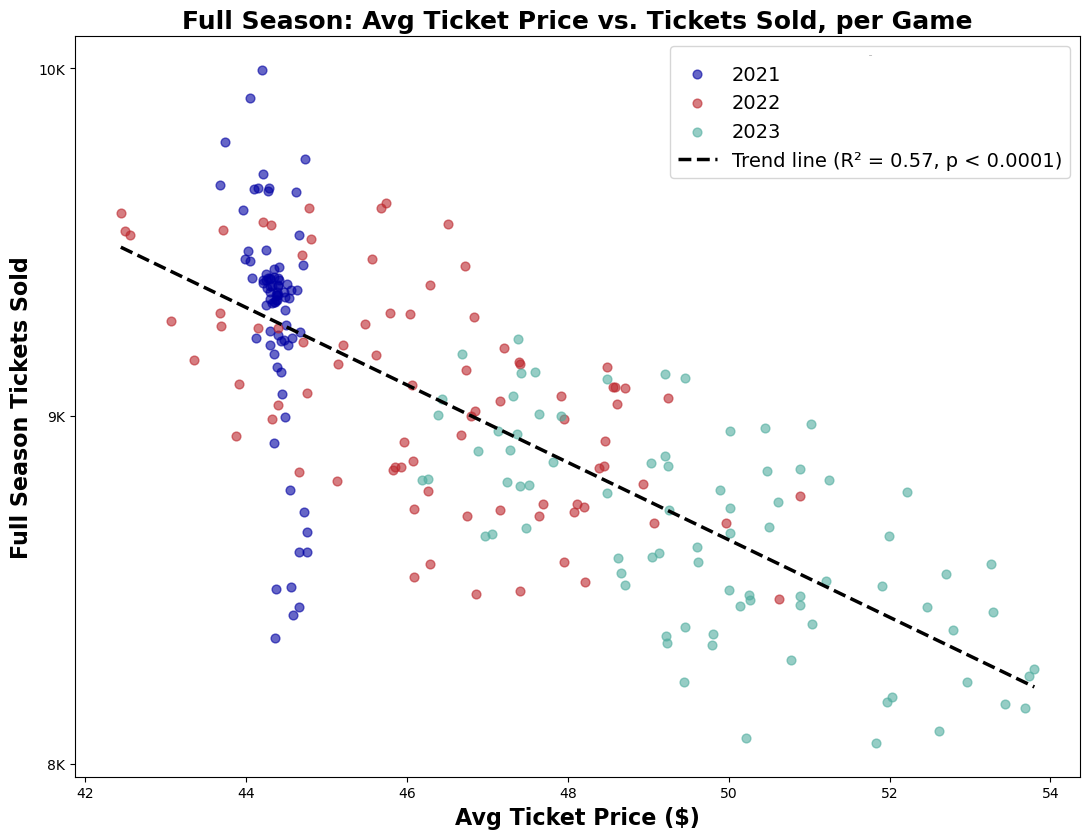

In [4]:
x = full['Full Season Avg Price ($)']
y = full['Full Season Tickets (#)']
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
fig, ax = plt.subplots(figsize=(11, 8.5))
# Color points by year for extra context
for year, color in YEAR_COLORS.items():
    mask = full['Year'] == year
    ax.scatter(full.loc[mask, 'Full Season Avg Price ($)'], full.loc[mask, 'Full Season Tickets (#)'],
               color=color, alpha=0.6, s=40, label=str(year))
# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linewidth=2.5, linestyle='dashed',
        label=f'Trend line (R² = {r_value**2:.2f}, p < 0.0001)')
ax.set_title('Full Season: Avg Ticket Price vs. Tickets Sold, per Game', **TITLE_STYLE)
ax.set_xlabel('Avg Ticket Price ($)', **LABEL_STYLE)
ax.set_ylabel('Full Season Tickets Sold', **LABEL_STYLE)
ax.set_yticks(np.arange(8000, 11000, 1000))
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(title='Year', loc='upper right', **LEGEND_STYLE)
plt.tight_layout()
plt.show()

### Seasonality Flattening vs. Partial Season Price Resilience

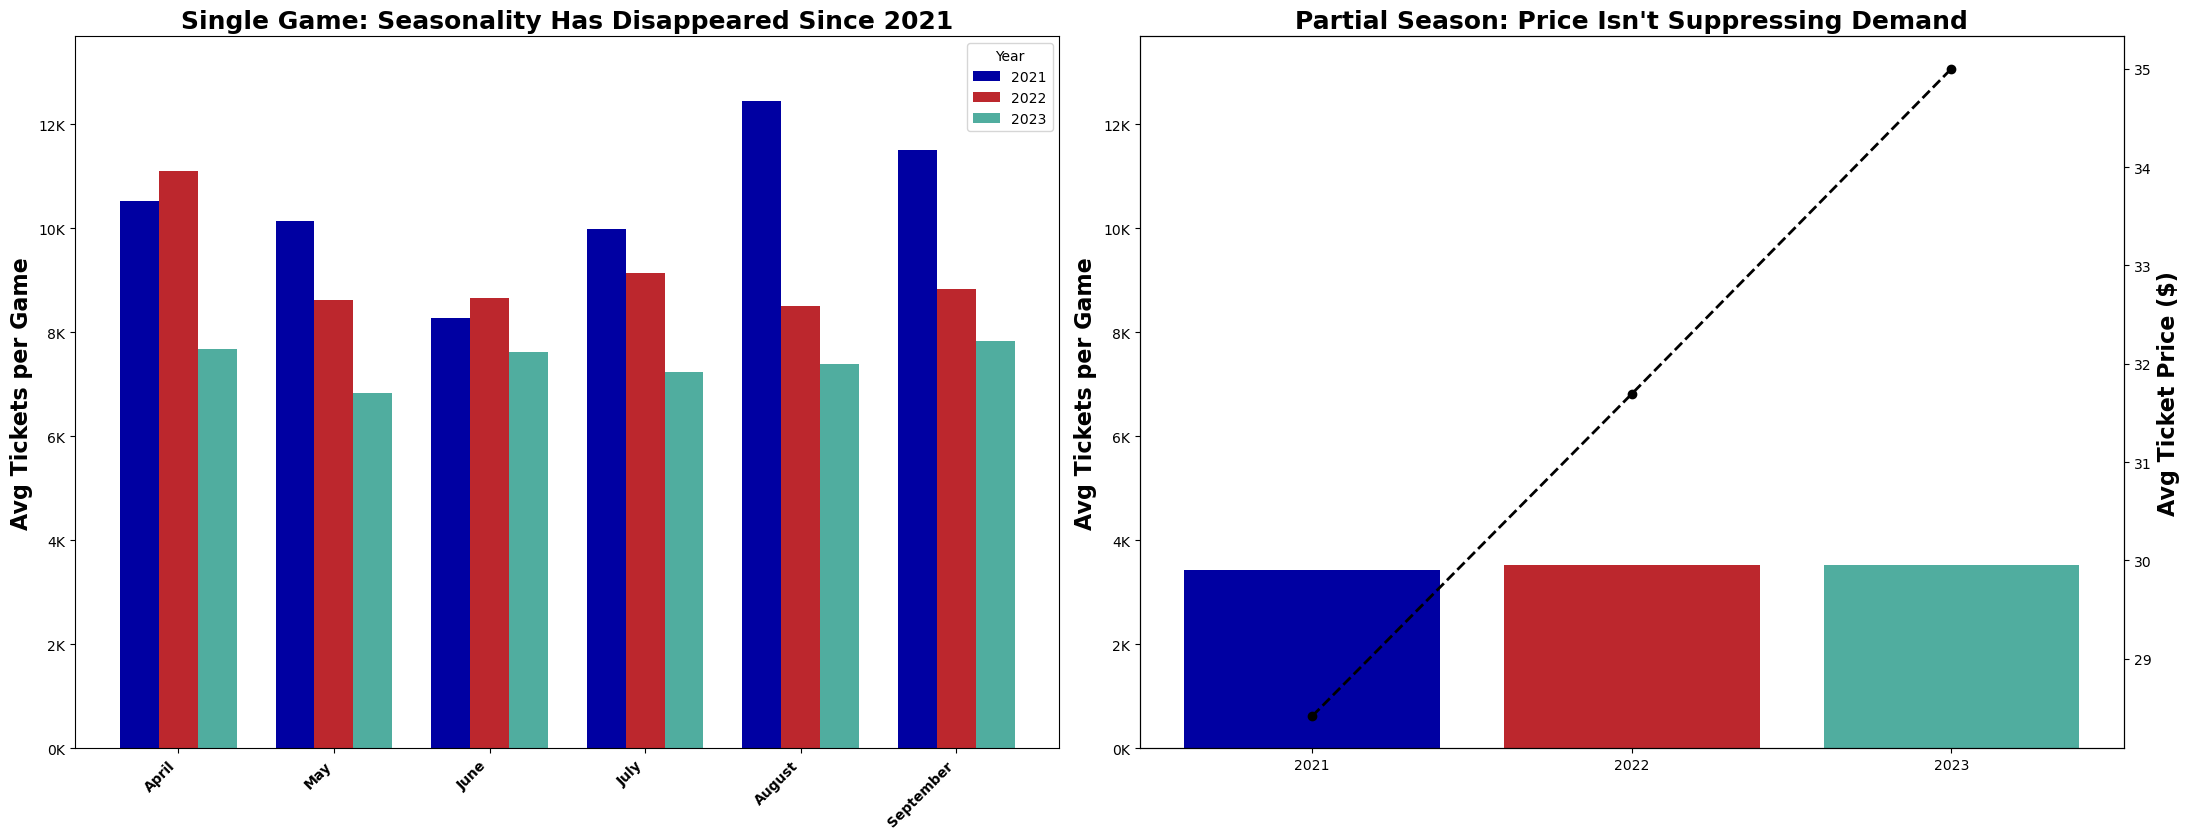

In [5]:
month_order = ['April','May','June','July','August','September']
target_days = ['Monday','Tuesday','Wednesday','Sunday']
d = full[full['Day of Week'].isin(target_days)]

month_pivot = d.groupby(['Year','Month'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=month_order)
ps_tickets = d.groupby('Year')['Partial Season Tickets (#)'].mean()
ps_price = d.groupby('Year')['Partial Season Avg Price ($)'].mean()

shared_max = max(month_pivot.max().max(), ps_tickets.max()) * 1.1

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# LEFT: Single Game seasonality flattening, by month
ax = axes[0]
x = range(len(month_order))
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax.bar([xi + i * BAR_WIDTH for xi in x], month_pivot.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax.set_title('Single Game: Seasonality Has Disappeared Since 2021', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in x])
ax.set_xticklabels(month_order, rotation=45, ha='right', fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.set_ylim(0, shared_max)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(title='Year', loc='upper right')

# RIGHT: Partial Season tickets & price, both climbing together
ax2 = axes[1]
years_str = [str(y) for y in ps_tickets.index]
ax2.bar(years_str, ps_tickets, color=[YEAR_COLORS[y] for y in ps_tickets.index])
ax2.set_title('Partial Season: Price Isn\'t Suppressing Demand', **TITLE_STYLE)
ax2.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax2.set_ylim(0, shared_max)
ax2.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

ax2_price = ax2.twinx()
ax2_price.plot(years_str, ps_price, color='black', marker='o', linewidth=2, linestyle='dashed', label='Avg Price')
ax2_price.set_ylabel('Avg Ticket Price ($)', **LABEL_STYLE)

plt.tight_layout()
plt.show()

### Total Portfolio Tickets & Revenue: Actual + Projected

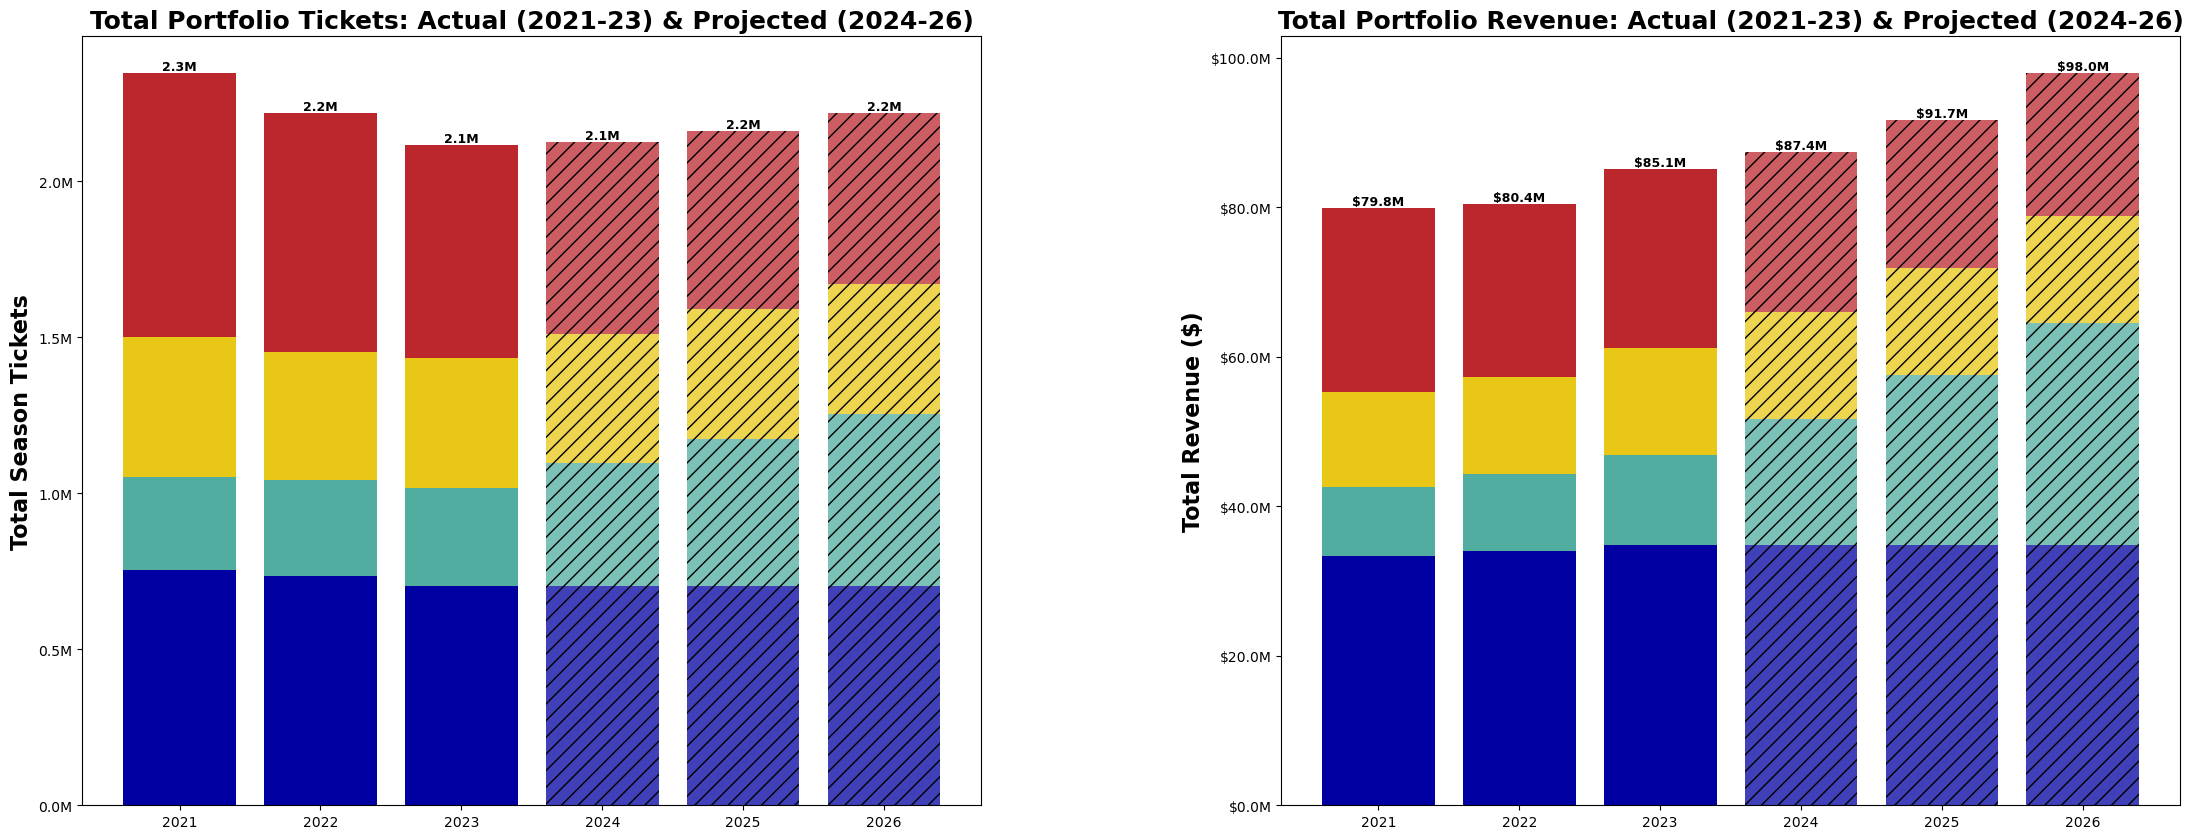

 Year Total Tickets Total Revenue
 2021     2,346,262   $79,841,410
 2022     2,216,724   $80,407,348
 2023     2,116,430   $85,056,446
 2024     2,123,668   $87,378,933
 2025     2,159,782   $91,696,969
 2026     2,218,764   $97,968,700


In [6]:
segments = ['Full Season', 'Partial Season', 'Group', 'Single Game']
tickets_hist = {seg: full.groupby('Year')[f'{seg} Tickets (#)'].sum().to_dict() for seg in segments}
revenue_hist = {seg: full.groupby('Year')[f'{seg} Revenue ($)'].sum().to_dict() for seg in segments}
price_hist = {seg: {yr: revenue_hist[seg][yr]/tickets_hist[seg][yr] for yr in [2021,2022,2023]} for seg in segments}

taper_fractions = {1: 1.0, 2: 2/3, 3: 1/3}
sg_2022, sg_2023 = tickets_hist['Single Game'][2022], tickets_hist['Single Game'][2023]
sg_decline_rate = (sg_2023 - sg_2022) / sg_2022

ps_p21, ps_p22, ps_p23 = price_hist['Partial Season'][2021], price_hist['Partial Season'][2022], price_hist['Partial Season'][2023]
ps_price_growth_rate = ((ps_p22-ps_p21)/ps_p21 + (ps_p23-ps_p22)/ps_p22) / 2

organic_contribution = {1: 7602, 2: 15387, 3: 23360}
plan_321_contribution = {1: 36867, 2: 73734, 3: 110601}
plan_369_contribution = {1: 34396, 2: 68609, 3: 102634}
ps_growth = {yr: organic_contribution[yr]+plan_321_contribution[yr]+plan_369_contribution[yr] for yr in [1,2,3]}

fs_totals = dict(tickets_hist['Full Season'])
group_totals = dict(tickets_hist['Group'])
ps_totals = dict(tickets_hist['Partial Season'])
sg_totals = dict(tickets_hist['Single Game'])

fs_prices = dict(price_hist['Full Season'])
group_prices = dict(price_hist['Group'])
ps_prices = dict(price_hist['Partial Season'])
sg_prices = dict(price_hist['Single Game'])

sg_running = sg_totals[2023]
for yr in [1,2,3]:
    year_num = 2023+yr
    yr_rate = sg_decline_rate*taper_fractions[yr]
    sg_running = sg_running*(1+yr_rate)
    sg_totals[year_num] = sg_running
    fs_totals[year_num] = fs_totals[2023]
    group_totals[year_num] = group_totals[2023]
    ps_totals[year_num] = ps_totals[2023] + ps_growth[yr]

    fs_prices[year_num] = fs_prices[2023]
    group_prices[year_num] = group_prices[2023]
    sg_prices[year_num] = sg_prices[2023]
    ps_prices[year_num] = ps_prices[2023]*(1+ps_price_growth_rate)**yr

all_years = [2021,2022,2023,2024,2025,2026]
years_labels = [str(y) for y in all_years]

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.08, 1])
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_legend.axis('off')

# LEFT: Total Portfolio Tickets
fs_vals = [fs_totals[y] for y in all_years]
ps_vals = [ps_totals[y] for y in all_years]
group_vals = [group_totals[y] for y in all_years]
sg_vals = [sg_totals[y] for y in all_years]
bottom1 = fs_vals
bottom2 = [f+p for f,p in zip(fs_vals, ps_vals)]
bottom3 = [f+p+g for f,p,g in zip(fs_vals, ps_vals, group_vals)]

bars_fs = ax.bar(years_labels, fs_vals, color=PALETTE[0], label='Full Season')
bars_ps = ax.bar(years_labels, ps_vals, bottom=bottom1, color=PALETTE[2], label='Partial Season')
bars_group = ax.bar(years_labels, group_vals, bottom=bottom2, color=PALETTE[3], label='Group')
bars_sg = ax.bar(years_labels, sg_vals, bottom=bottom3, color=PALETTE[1], label='Single Game')
for i, y in enumerate(all_years):
    if y > 2023:
        for bars in [bars_fs, bars_ps, bars_group, bars_sg]:
            bars[i].set_hatch('//')
            bars[i].set_alpha(0.75)
for i in range(6):
    total = fs_vals[i]+ps_vals[i]+group_vals[i]+sg_vals[i]
    ax.text(i, total, f'{total/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Total Portfolio Tickets: Actual (2021-23) & Projected (2024-26)', **TITLE_STYLE)
ax.set_ylabel('Total Season Tickets', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(millions_plain_formatter))

# RIGHT: Total Portfolio Revenue
fs_rev = [fs_totals[y]*fs_prices[y] for y in all_years]
ps_rev = [ps_totals[y]*ps_prices[y] for y in all_years]
group_rev = [group_totals[y]*group_prices[y] for y in all_years]
sg_rev = [sg_totals[y]*sg_prices[y] for y in all_years]
rbottom1 = fs_rev
rbottom2 = [f+p for f,p in zip(fs_rev, ps_rev)]
rbottom3 = [f+p+g for f,p,g in zip(fs_rev, ps_rev, group_rev)]

rbars_fs = ax2.bar(years_labels, fs_rev, color=PALETTE[0], label='Full Season')
rbars_ps = ax2.bar(years_labels, ps_rev, bottom=rbottom1, color=PALETTE[2], label='Partial Season')
rbars_group = ax2.bar(years_labels, group_rev, bottom=rbottom2, color=PALETTE[3], label='Group')
rbars_sg = ax2.bar(years_labels, sg_rev, bottom=rbottom3, color=PALETTE[1], label='Single Game')
for i, y in enumerate(all_years):
    if y > 2023:
        for bars in [rbars_fs, rbars_ps, rbars_group, rbars_sg]:
            bars[i].set_hatch('//')
            bars[i].set_alpha(0.75)
for i in range(6):
    total = fs_rev[i]+ps_rev[i]+group_rev[i]+sg_rev[i]
    ax2.text(i, total, f'${total/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Total Portfolio Revenue: Actual (2021-23) & Projected (2024-26)', **TITLE_STYLE)
ax2.set_ylabel('Total Revenue ($)', **LABEL_STYLE)
ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

summary_rows = []
for y in all_years:
    total_tix = fs_totals[y]+ps_totals[y]+group_totals[y]+sg_totals[y]
    total_rev = (fs_totals[y]*fs_prices[y])+(ps_totals[y]*ps_prices[y])+(group_totals[y]*group_prices[y])+(sg_totals[y]*sg_prices[y])
    summary_rows.append({'Year': y, 'Total Tickets': f'{total_tix:,.0f}', 'Total Revenue': f'${total_rev:,.0f}'})
print(pd.DataFrame(summary_rows).to_string(index=False))

### Total Tickets, Revenue & Avg Price by Segment

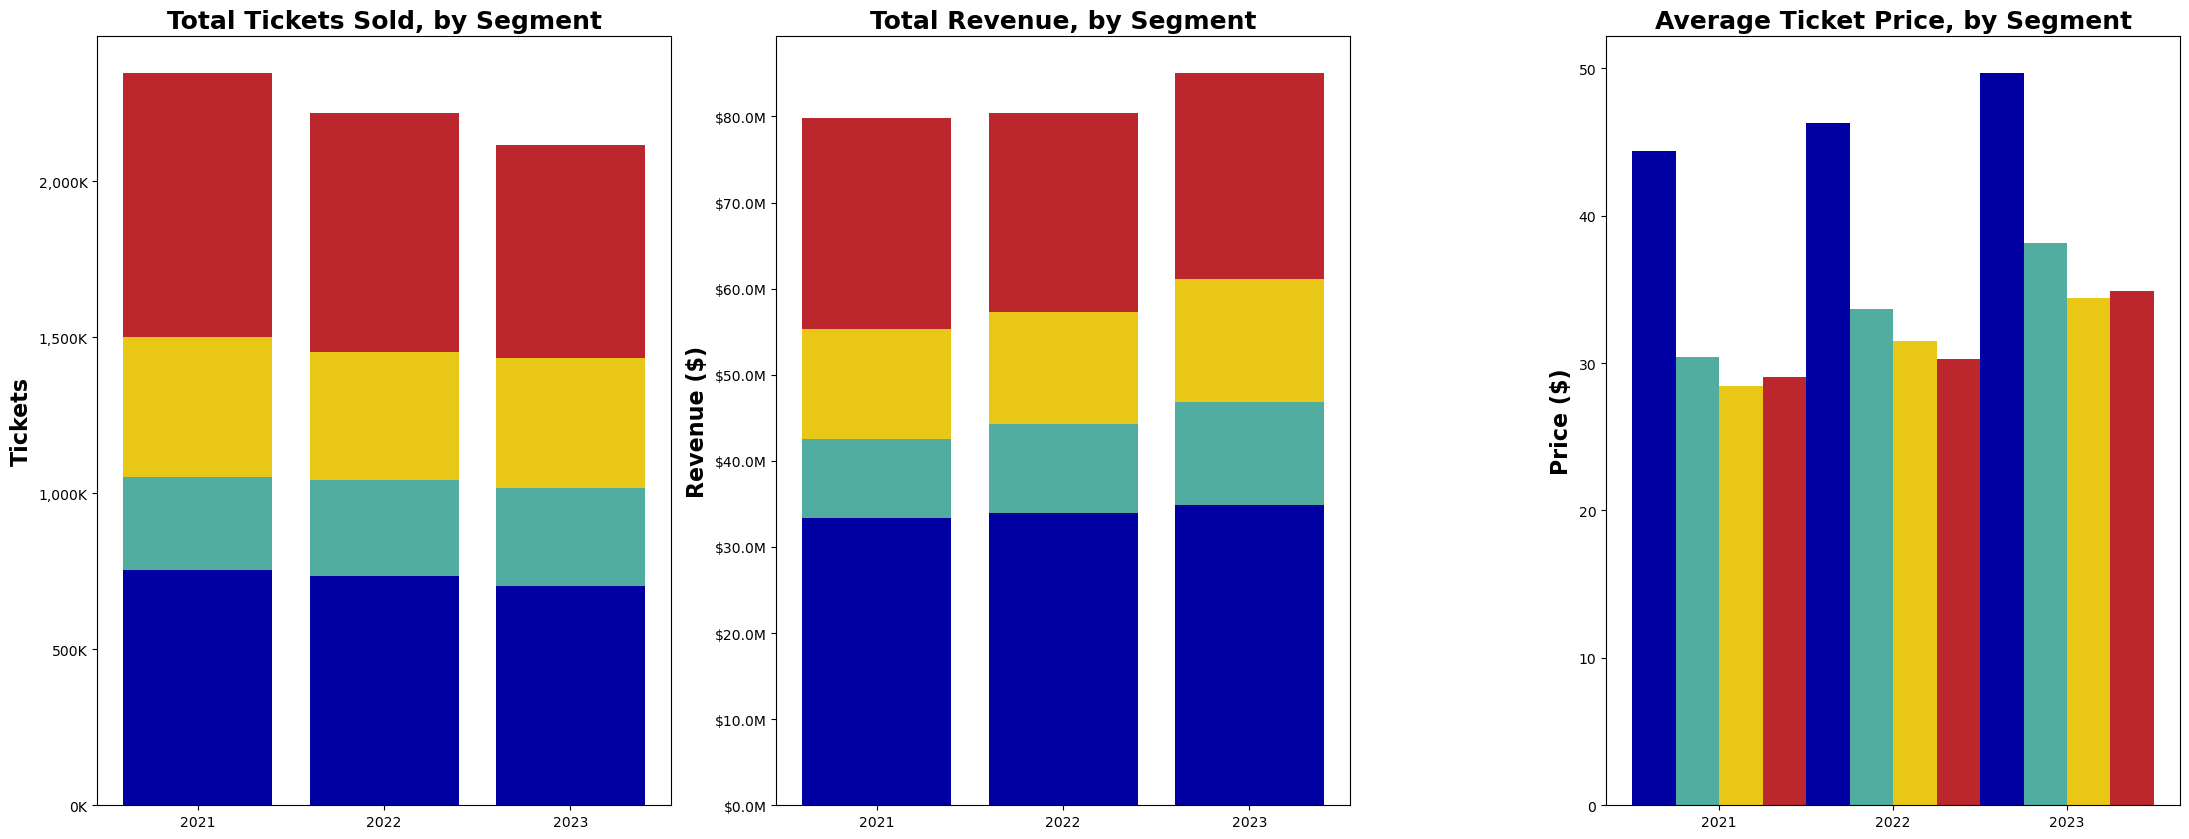

In [7]:
fs_tix = full.groupby('Year')['Full Season Tickets (#)'].sum()
ps_tix = full.groupby('Year')['Partial Season Tickets (#)'].sum()
grp_tix = full.groupby('Year')['Group Tickets (#)'].sum()
sg_tix = full.groupby('Year')['Single Game Tickets (#)'].sum()

fs_rev = full.groupby('Year')['Full Season Revenue ($)'].sum()
ps_rev = full.groupby('Year')['Partial Season Revenue ($)'].sum()
grp_rev = full.groupby('Year')['Group Revenue ($)'].sum()
sg_rev = full.groupby('Year')['Single Game Revenue ($)'].sum()

fs_price = fs_rev/fs_tix
ps_price = ps_rev/ps_tix
grp_price = grp_rev/grp_tix
sg_price = sg_rev/sg_tix

years = fs_tix.index.astype(str)

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.08, 1])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax_gap = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[3])
ax_gap.axis('off')

# LEFT: Total Tickets Sold, stacked by segment
ax0.bar(years, fs_tix, color=PALETTE[0], label='Full Season')
ax0.bar(years, ps_tix, bottom=fs_tix, color=PALETTE[2], label='Partial Season')
ax0.bar(years, grp_tix, bottom=fs_tix+ps_tix, color=PALETTE[3], label='Group')
ax0.bar(years, sg_tix, bottom=fs_tix+ps_tix+grp_tix, color=PALETTE[1], label='Single Game')
ax0.set_title('Total Tickets Sold, by Segment', **TITLE_STYLE)
ax0.set_ylabel('Tickets', **LABEL_STYLE)
ax0.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# MIDDLE: Total Revenue, stacked by segment
ax1.bar(years, fs_rev, color=PALETTE[0], label='Full Season')
ax1.bar(years, ps_rev, bottom=fs_rev, color=PALETTE[2], label='Partial Season')
ax1.bar(years, grp_rev, bottom=fs_rev+ps_rev, color=PALETTE[3], label='Group')
ax1.bar(years, sg_rev, bottom=fs_rev+ps_rev+grp_rev, color=PALETTE[1], label='Single Game')
ax1.set_title('Total Revenue, by Segment', **TITLE_STYLE)
ax1.set_ylabel('Revenue ($)', **LABEL_STYLE)
ax1.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

# RIGHT: Average Ticket Price, grouped by segment
x = range(len(years))
ax2.bar([xi-1.5*BAR_WIDTH for xi in x], fs_price, width=BAR_WIDTH, color=PALETTE[0], label='Full Season')
ax2.bar([xi-0.5*BAR_WIDTH for xi in x], ps_price, width=BAR_WIDTH, color=PALETTE[2], label='Partial Season')
ax2.bar([xi+0.5*BAR_WIDTH for xi in x], grp_price, width=BAR_WIDTH, color=PALETTE[3], label='Group')
ax2.bar([xi+1.5*BAR_WIDTH for xi in x], sg_price, width=BAR_WIDTH, color=PALETTE[1], label='Single Game')
ax2.set_xticks(list(x))
ax2.set_xticklabels(years)
ax2.set_title('Average Ticket Price, by Segment', **TITLE_STYLE)
ax2.set_ylabel('Price ($)', **LABEL_STYLE)

plt.tight_layout()
plt.show()

### Partial Season: M/T/W/Sun Avg Tickets & Price

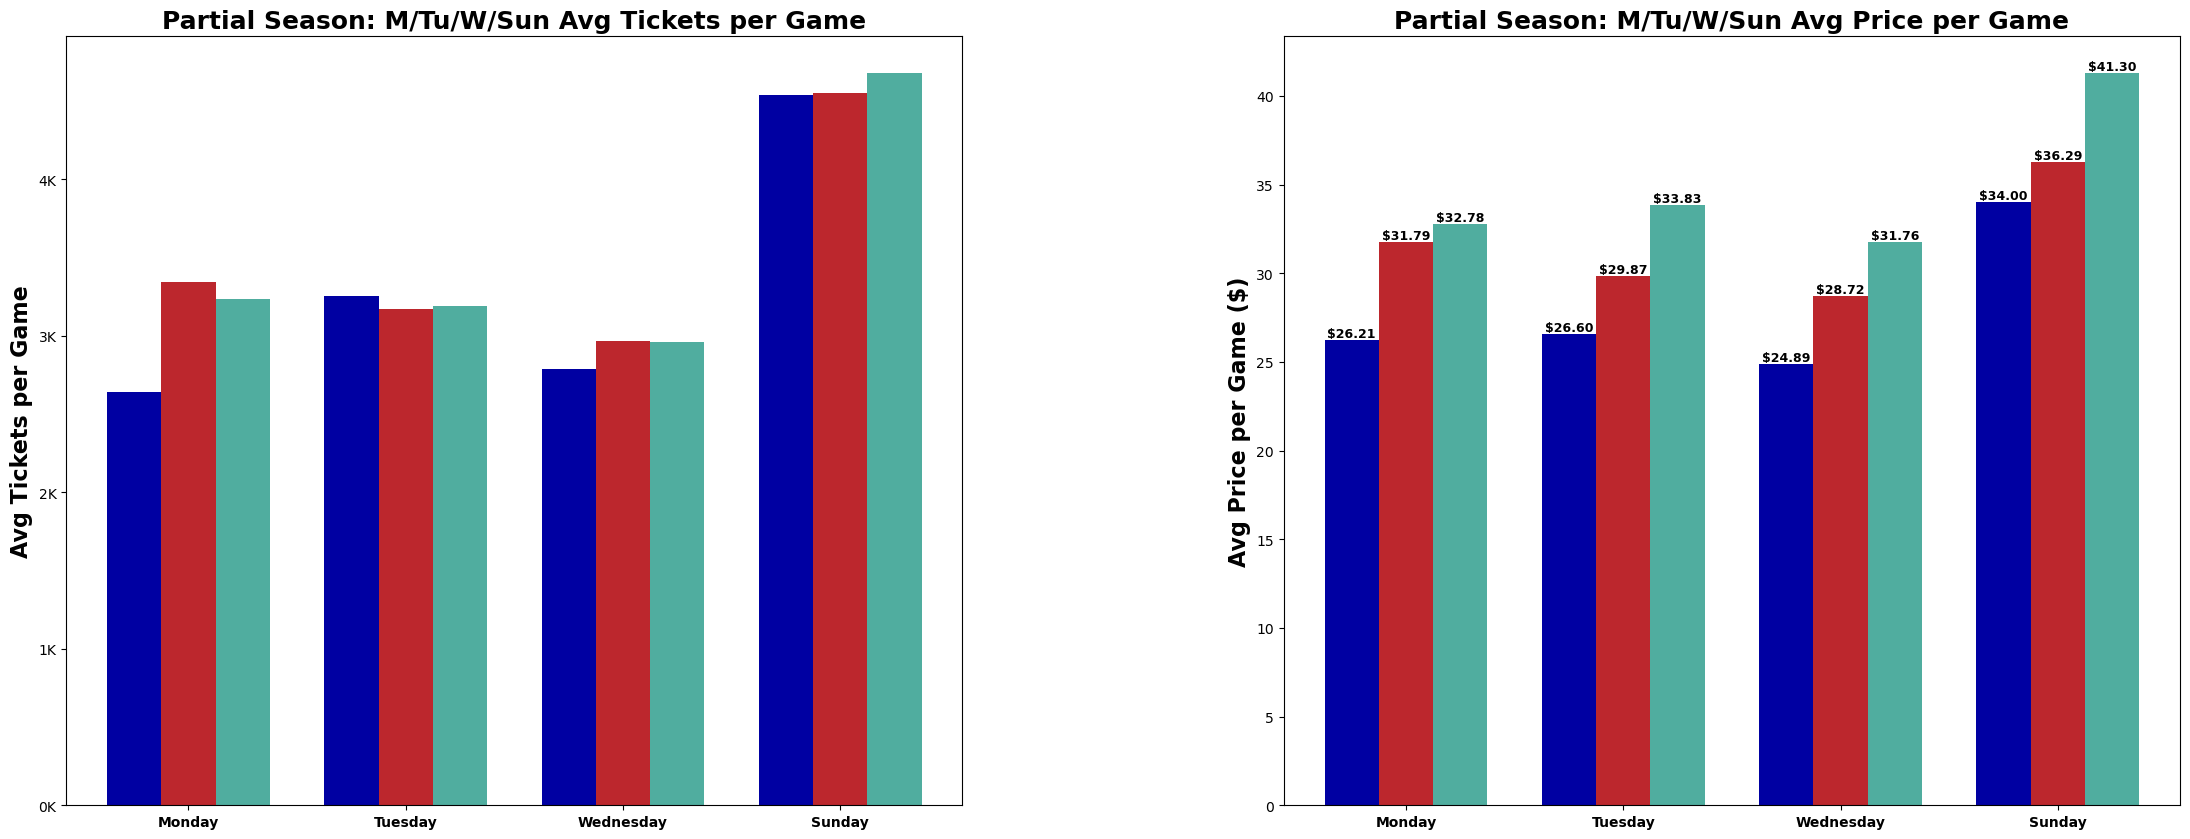

In [8]:
mtws = ['Monday','Tuesday','Wednesday','Sunday']
ticket_actual = {}
price_actual = {}
for day in mtws:
    d = full[full['Day of Week']==day]
    ticket_actual[day] = d.groupby('Year')['Partial Season Tickets (#)'].mean().to_dict()
    price_actual[day] = d.groupby('Year')['Partial Season Avg Price ($)'].mean().to_dict()

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.2, 1])
ax = fig.add_subplot(gs[0])
ax_gap = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_gap.axis('off')

x = range(len(mtws))

# LEFT: avg tickets per game, actual 2021-2023
for i, yr in enumerate(YEARS):
    vals = [ticket_actual[day][yr] for day in mtws]
    ax.bar([xi + i*BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, label=str(yr), color=YEAR_COLORS[yr])
ax.set_title('Partial Season: M/Tu/W/Sun Avg Tickets per Game', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in x])
ax.set_xticklabels(mtws, fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# RIGHT: avg price per game, actual 2021-2023
for i, yr in enumerate(YEARS):
    vals = [price_actual[day][yr] for day in mtws]
    bars = ax2.bar([xi + i*BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, label=str(yr), color=YEAR_COLORS[yr])
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x()+bar.get_width()/2, v, f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Partial Season: M/Tu/W/Sun Avg Price per Game', **TITLE_STYLE)
ax2.set_xticks([xi + BAR_WIDTH for xi in x])
ax2.set_xticklabels(mtws, fontweight='bold')
ax2.set_ylabel('Avg Price per Game ($)', **LABEL_STYLE)

plt.tight_layout()
plt.show()

### Single Game: Avg Tickets & Games Scheduled, M/T/W/Sun

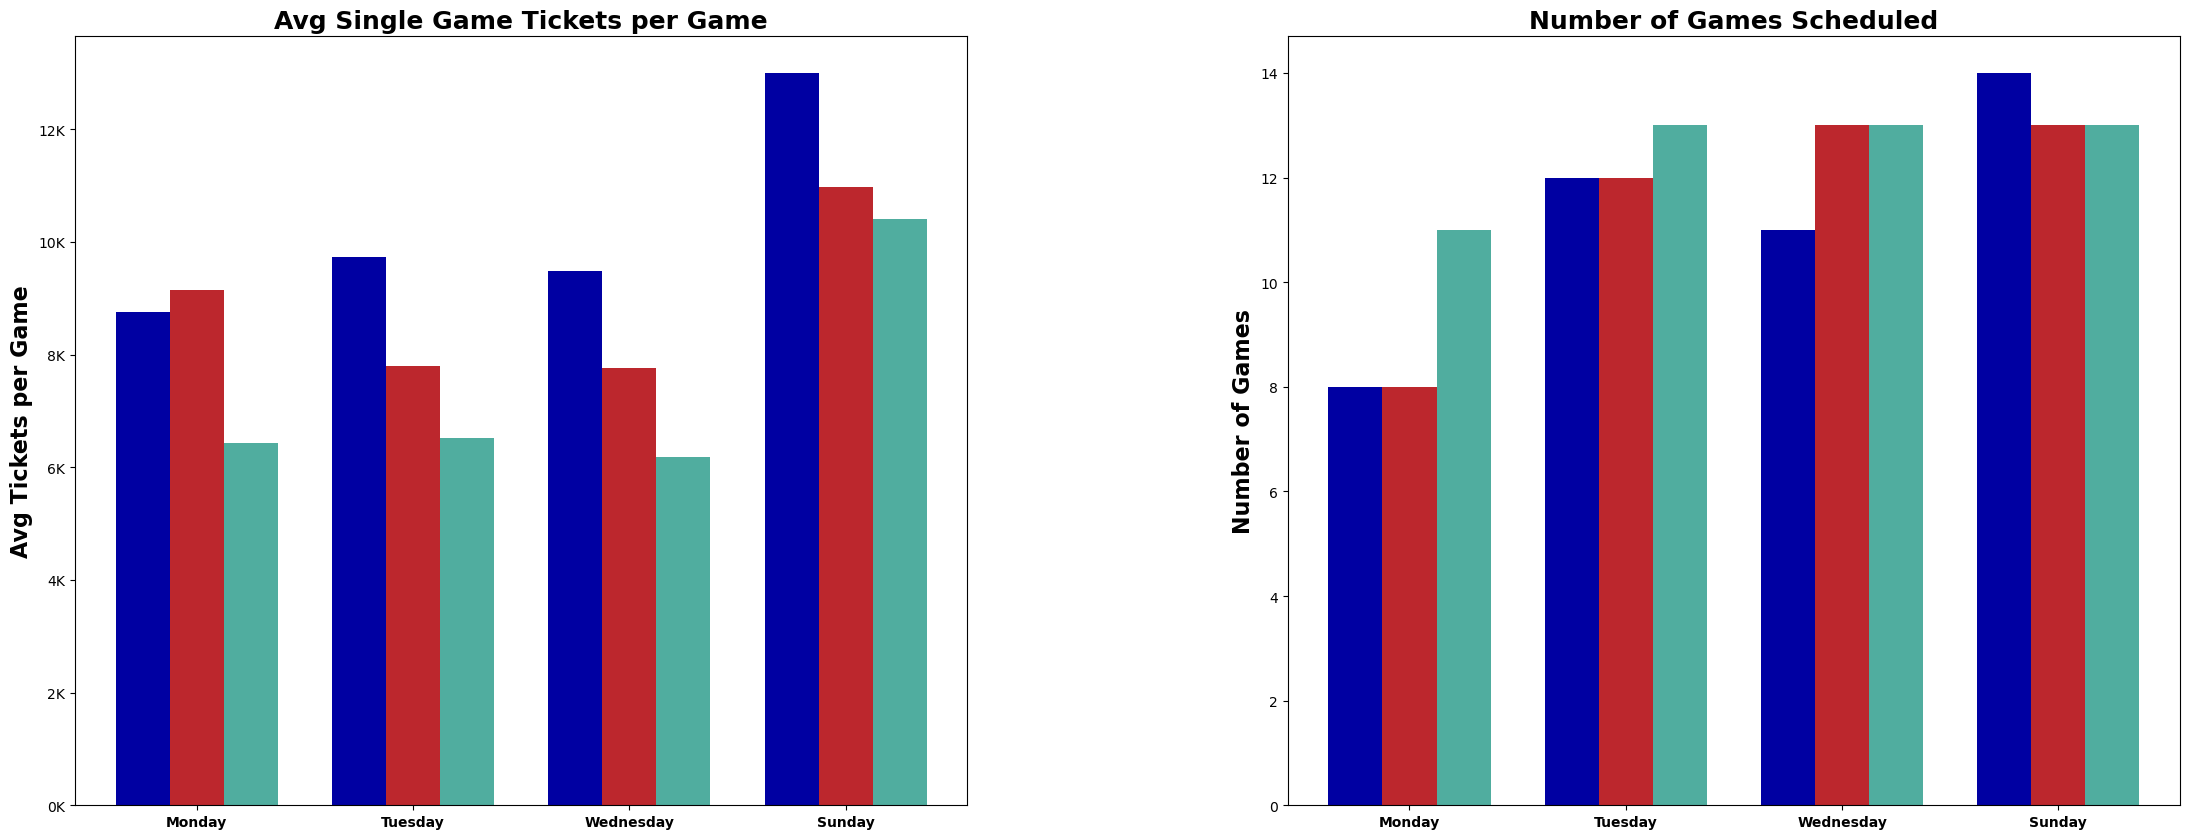

In [9]:
mtws_order = ['Monday', 'Tuesday', 'Wednesday', 'Sunday']
ticket_pivot_mtws = full.groupby(['Year', 'Day of Week'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=mtws_order)
game_counts_mtws = full.groupby(['Year', 'Day of Week']).size().unstack().reindex(columns=mtws_order)

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.2, 1])
ax = fig.add_subplot(gs[0])
ax_gap = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_gap.axis('off')

xi_range = range(len(mtws_order))

# LEFT: Avg tickets per game, YoY
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax.bar([xi + i * BAR_WIDTH for xi in xi_range], ticket_pivot_mtws.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax.set_title('Avg Single Game Tickets per Game', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in xi_range])
ax.set_xticklabels(mtws_order, fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# RIGHT: Number of games scheduled, YoY
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax2.bar([xi + i * BAR_WIDTH for xi in xi_range], game_counts_mtws.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax2.set_title('Number of Games Scheduled', **TITLE_STYLE)
ax2.set_xticks([xi + BAR_WIDTH for xi in xi_range])
ax2.set_xticklabels(mtws_order, fontweight='bold')
ax2.set_ylabel('Number of Games', **LABEL_STYLE)

plt.tight_layout()
plt.show()

### No-Show Rate by Day of Week, Month, and Day/Night

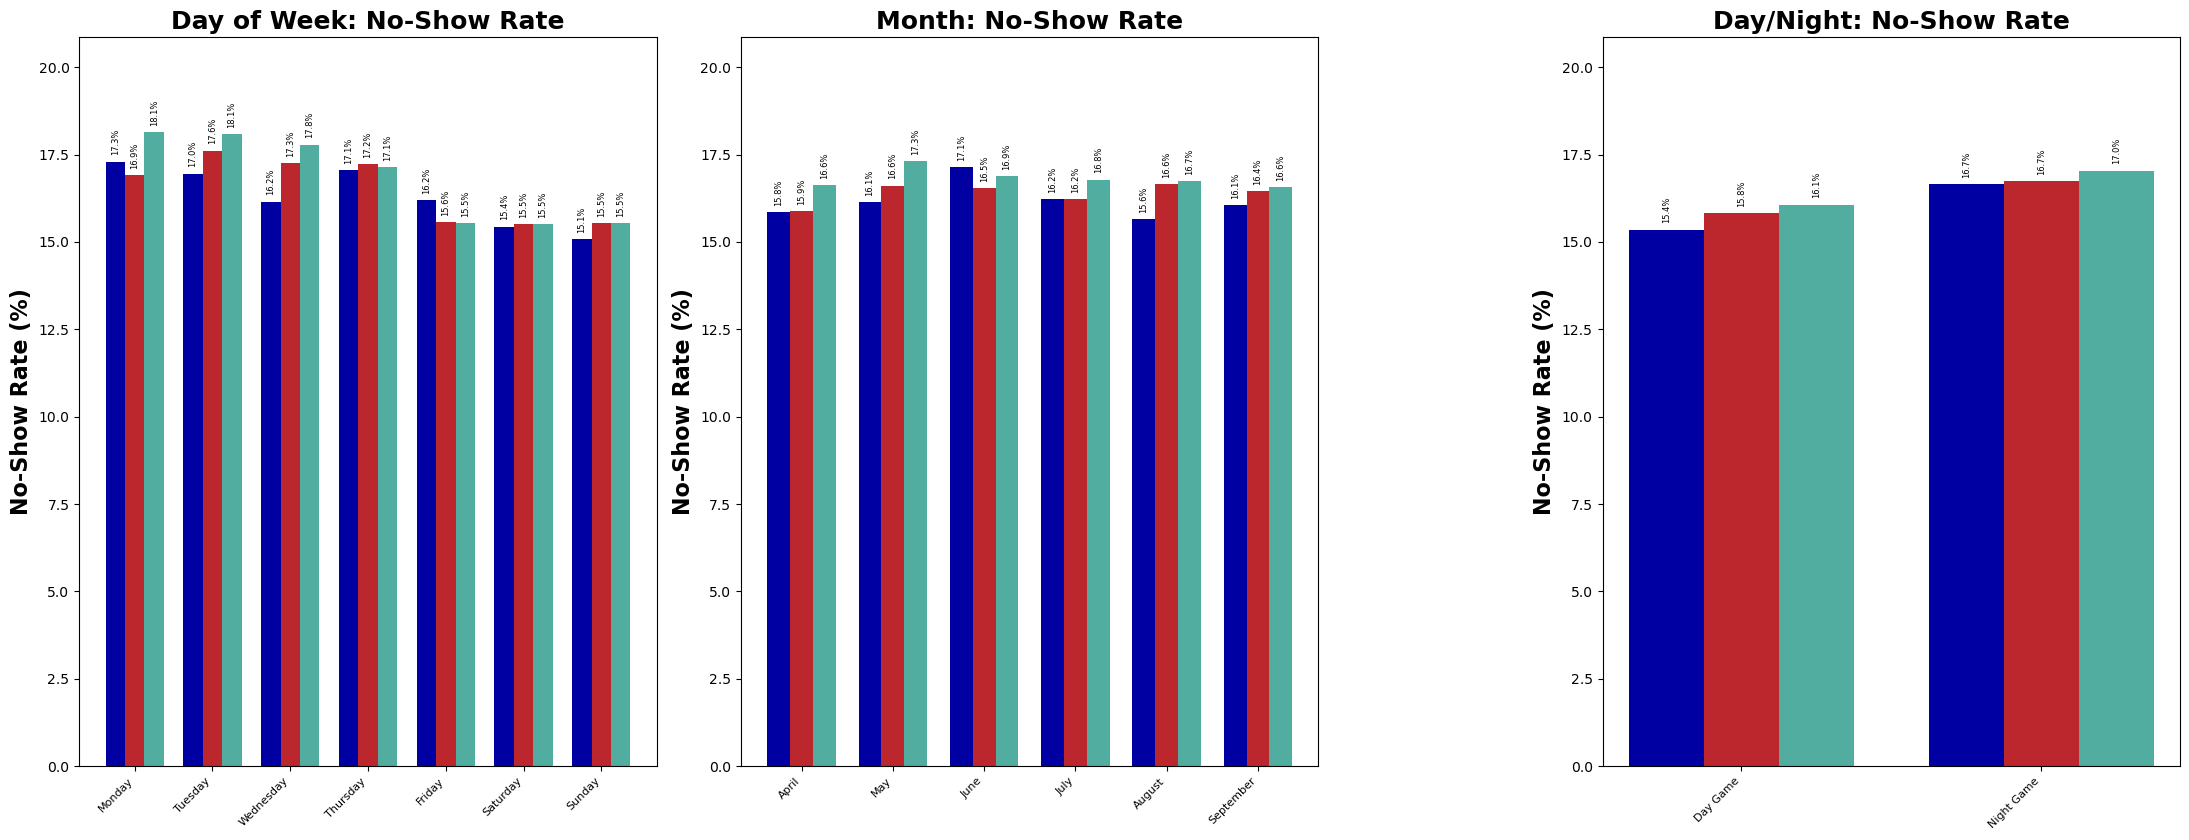

In [10]:
cuts = [
    ('Day of Week', 'Day of Week', DOW_ORDER),
    ('Month', 'Month', MONTH_ORDER),
    ('Day/Night', 'Day/Night', DAYNIGHT_ORDER),
]

# Shared max for consistent scale across all three panels
max_rate = 0
for label, group_col, order in cuts:
    rate_pivot = full.groupby(['Year', group_col])['No-Show Rate'].mean().unstack().reindex(columns=order) * 100
    max_rate = max(max_rate, rate_pivot.max().max())

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.2, 1])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax_gap = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[3])
ax_gap.axis('off')

axes_list = [ax0, ax1, ax2]

for ax, (label, group_col, order) in zip(axes_list, cuts):
    x = range(len(order))
    rate_pivot = full.groupby(['Year', group_col])['No-Show Rate'].mean().unstack().reindex(columns=order) * 100
    for i, year in enumerate(YEARS):
        vals = rate_pivot.loc[year].fillna(0) if year in rate_pivot.index else pd.Series(0, index=order)
        bars = ax.bar([xi + i * BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, color=YEAR_COLORS[year], label=str(year))
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, v + max_rate*0.01, f'{v:.1f}%',
                         ha='center', va='bottom', fontsize=6, rotation=90)
    ax.set_xticks([xi + BAR_WIDTH for xi in x])
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{label}: No-Show Rate', **TITLE_STYLE)
    ax.set_ylabel('No-Show Rate (%)', **LABEL_STYLE)
    ax.set_ylim(0, max_rate * 1.15)

plt.tight_layout()
plt.show()

### Avg Price, M/T/W Combined: Single Game vs. Partial Season

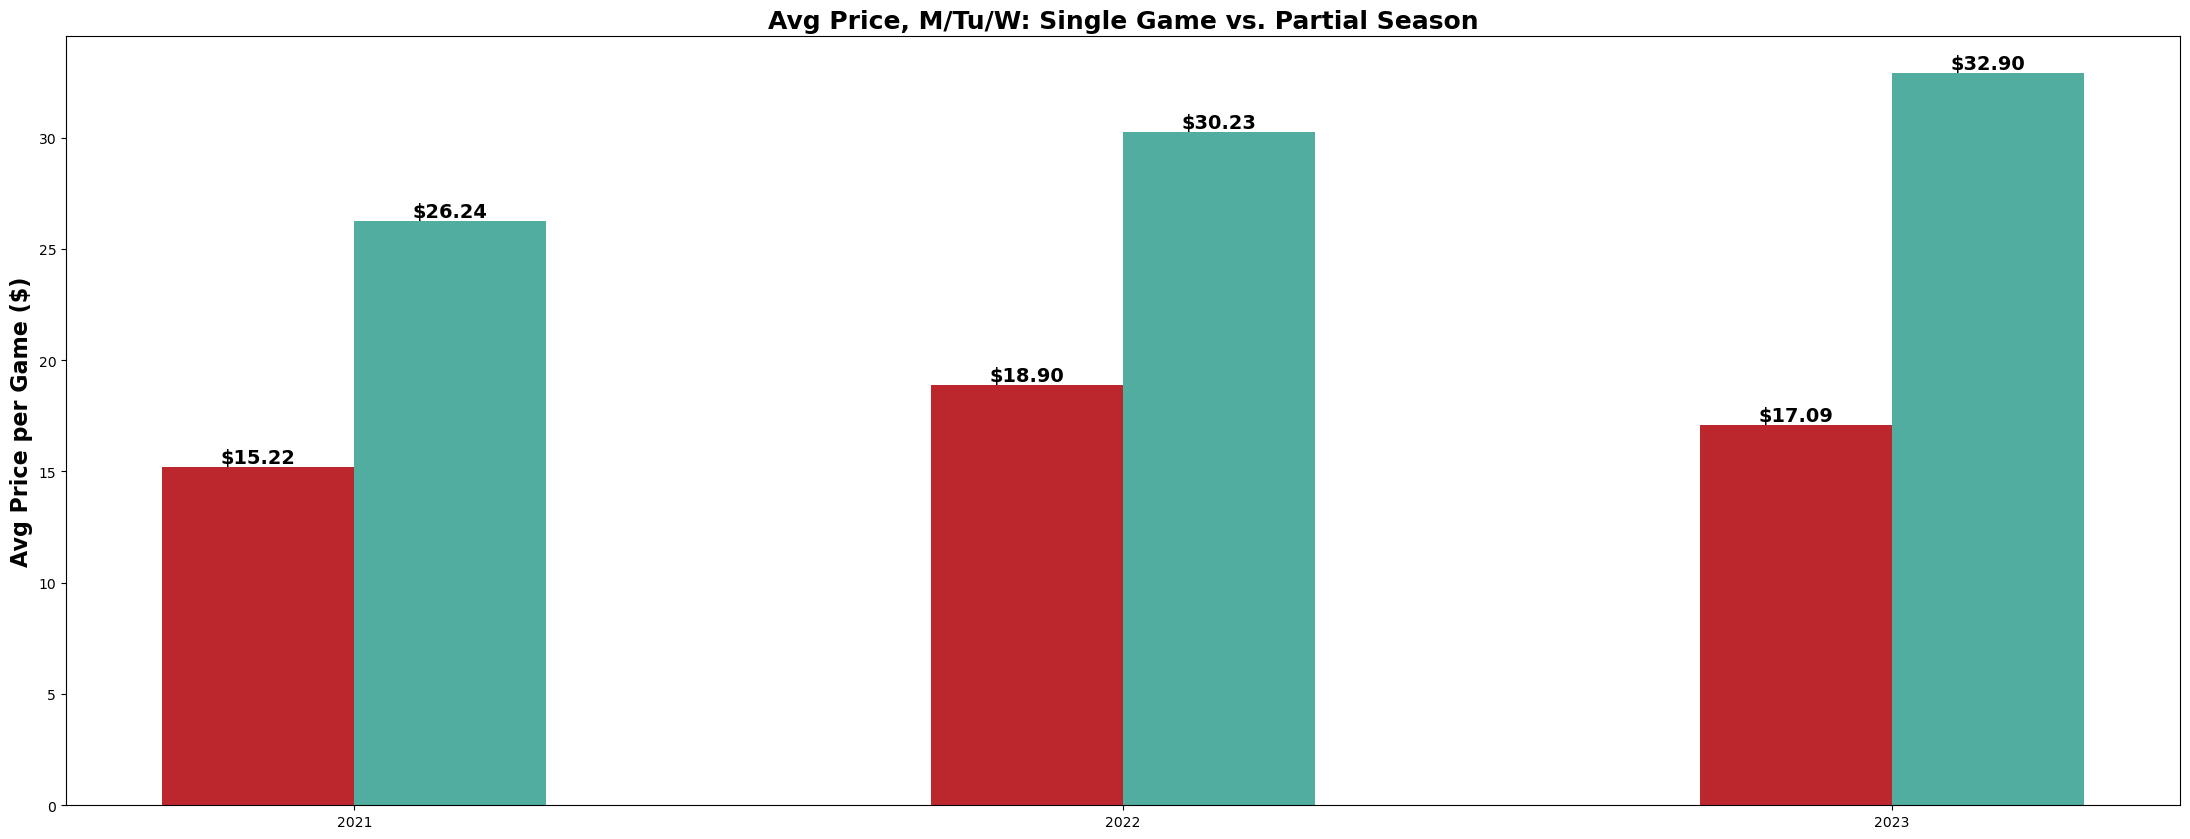

In [11]:
mtw = ['Monday','Tuesday','Wednesday']
d = full[full['Day of Week'].isin(mtw)]

sg_price_yoy = d.groupby('Year').apply(lambda x: x['Single Game Revenue ($)'].sum()/x['Single Game Tickets (#)'].sum())
ps_price_yoy = d.groupby('Year').apply(lambda x: x['Partial Season Revenue ($)'].sum()/x['Partial Season Tickets (#)'].sum())

fig, ax = plt.subplots(figsize=FIGSIZE)
x = range(len(YEARS))

bars_sg = ax.bar([xi - BAR_WIDTH/2 for xi in x], sg_price_yoy.reindex(YEARS), width=BAR_WIDTH, color=PALETTE[1], label='Single Game')
bars_ps = ax.bar([xi + BAR_WIDTH/2 for xi in x], ps_price_yoy.reindex(YEARS), width=BAR_WIDTH, color=PALETTE[2], label='Partial Season')

for bar, v in zip(bars_sg, sg_price_yoy.reindex(YEARS)):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'${v:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
for bar, v in zip(bars_ps, ps_price_yoy.reindex(YEARS)):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'${v:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels([str(y) for y in YEARS])
ax.set_title('Avg Price, M/Tu/W: Single Game vs. Partial Season', **TITLE_STYLE)
ax.set_ylabel('Avg Price per Game ($)', **LABEL_STYLE)

plt.tight_layout()
plt.show()

### Avg Price by Day, M/T/W: Single Game vs. Partial Season

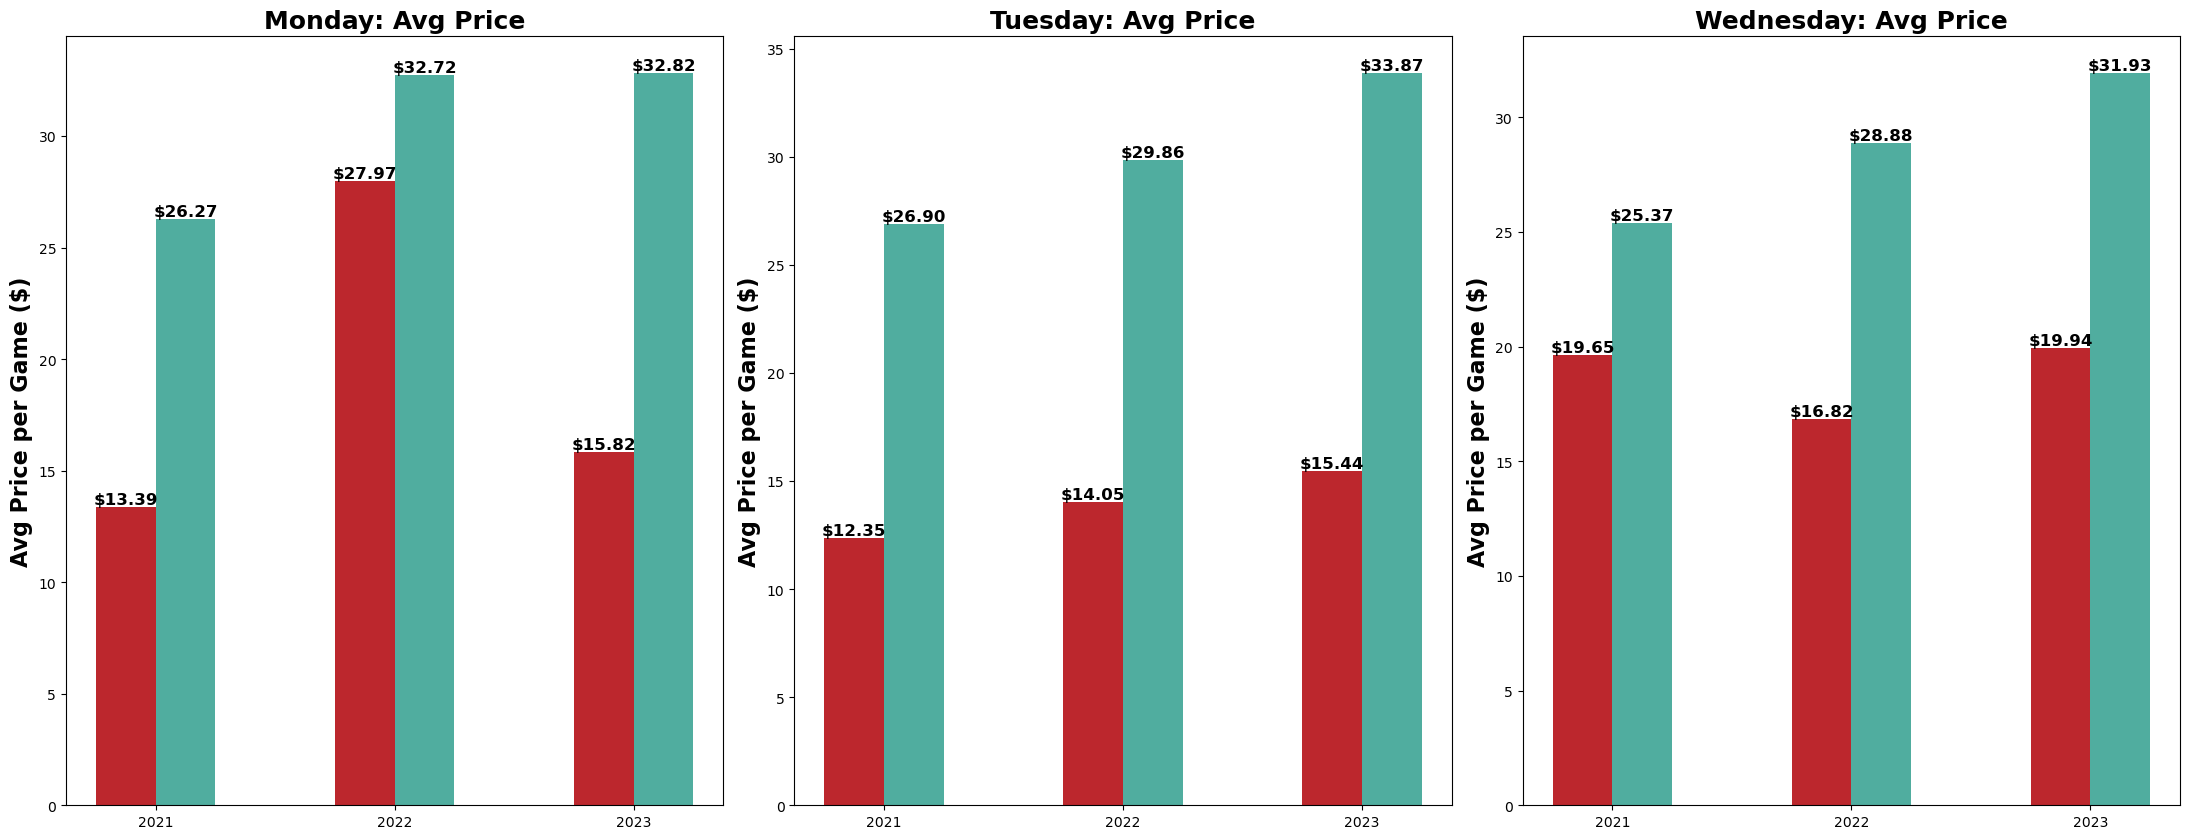

In [13]:
mtw = ['Monday','Tuesday','Wednesday']

sg_price = {}
ps_price = {}
for day in mtw:
    d = full[full['Day of Week']==day]
    sg_price[day] = (d.groupby('Year').apply(lambda x: x['Single Game Revenue ($)'].sum()/x['Single Game Tickets (#)'].sum())).reindex(YEARS)
    ps_price[day] = (d.groupby('Year').apply(lambda x: x['Partial Season Revenue ($)'].sum()/x['Partial Season Tickets (#)'].sum())).reindex(YEARS)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)

for ax, day in zip(axes, mtw):
    x = range(len(YEARS))
    bars_sg = ax.bar([xi - BAR_WIDTH/2 for xi in x], sg_price[day], width=BAR_WIDTH, color=PALETTE[1], label='Single Game')
    bars_ps = ax.bar([xi + BAR_WIDTH/2 for xi in x], ps_price[day], width=BAR_WIDTH, color=PALETTE[2], label='Partial Season')

    for bar, v in zip(bars_sg, sg_price[day]):
        ax.text(bar.get_x()+bar.get_width()/2, v, f'${v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    for bar, v in zip(bars_ps, ps_price[day]):
        ax.text(bar.get_x()+bar.get_width()/2, v, f'${v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_xticks(list(x))
    ax.set_xticklabels([str(y) for y in YEARS])
    ax.set_title(f'{day}: Avg Price', **TITLE_STYLE)
    ax.set_ylabel('Avg Price per Game ($)', **LABEL_STYLE)

plt.tight_layout()
plt.show()

### Seasonality in Single Game Tickets

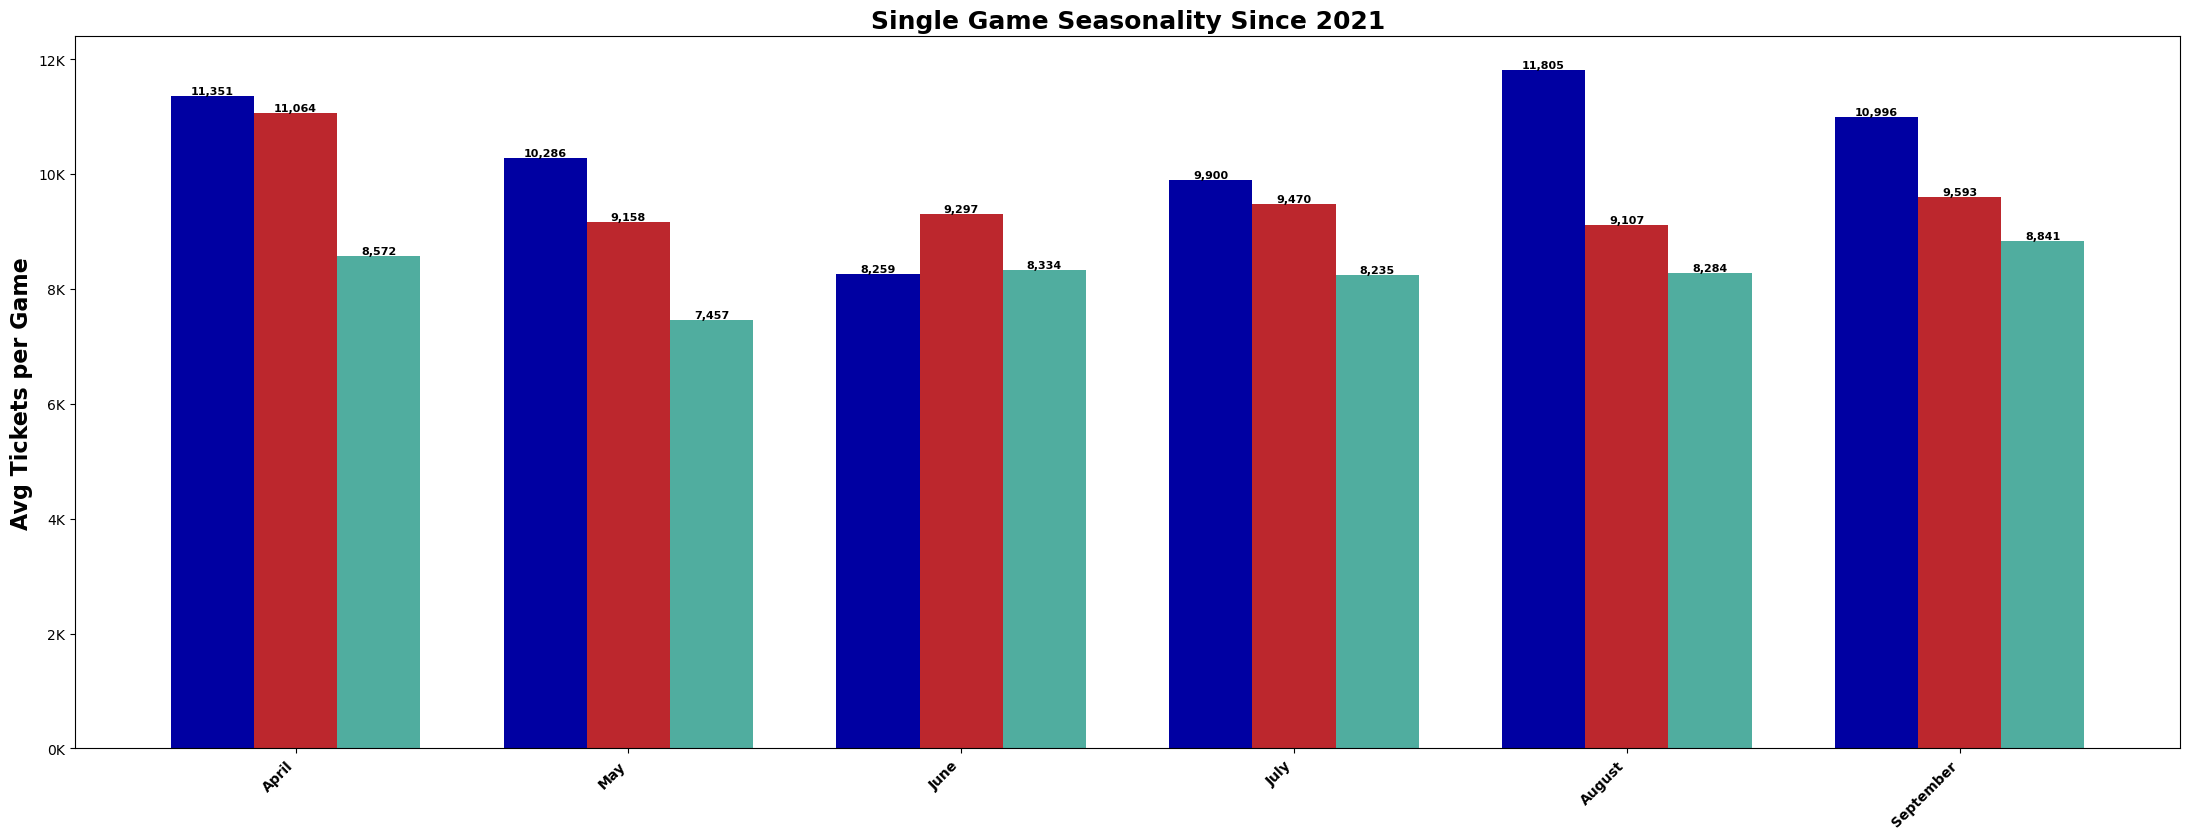

In [16]:
month_order = ['April','May','June','July','August','September']
ticket_pivot = full.groupby(['Year','Month'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=month_order)

fig, ax = plt.subplots(figsize=FIGSIZE)
x = range(len(month_order))
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    bars = ax.bar([xi + i * BAR_WIDTH for xi in x], ticket_pivot.loc[year], width=BAR_WIDTH, color=color)
    for bar, v in zip(bars, ticket_pivot.loc[year]):
        ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Single Game Seasonality Since 2021', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in x])
ax.set_xticklabels(month_order, rotation=45, ha='right', fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()